## 4.4 箱型圖（Box Plot）

### 1. 定義  
箱型圖利用矩形箱子與延伸的鬚線方式，呈現資料的分布狀態與五種指標數值總結（包含最小值、第一四分位數、中位數、第三四分位數及最大值），適合用於比較多組數據的集中趨勢與辨識離群值。


### 2. 範例圖表與說明

  <img src="https://raw.githubusercontent.com/jacklin92/ch4/main/Box-00.png" width="400">


**觀察與解釋**：  
圖中呈現不同產品類別的每日銷售額分布情況。Electronics 銷售中位數最高（約 310 美元），為主力營收來源但波動幅度最大；Books 銷售中位數最低（約 80 美元）但表現最為穩定。適合用來比較各產品線業績的集中趨勢與辨識離群值，並最佳化銷售預測與庫存管理。


### 3. 適用情況
- 比較多組資料的分布情形與集中趨勢
- 辨識資料中的離群值與偏態


### 4. 優缺點
- **優點**：
  - 一張圖同時呈現五數摘要（最小值、Q1、中位數、Q3、最大值）與離群值
  - 適合多組資料並排比較
- **缺點**：
  - 無法呈現資料分布的細部形狀（如雙峰分布）
  - 對不熟悉統計的讀者需要額外說明


### 5. 實際案例與圖表

- **醫療領域：不同年齡層的住院天數分布**  
    <img src="https://raw.githubusercontent.com/jacklin92/ch4/main/Box-01.png" width="400">

  **觀察與解釋**：隨著年齡層增長，病患的住院天數中位數顯著增加（從「40歲以下」的約 3 天上升至「60歲以上」的近 8 天），且資料的分布範圍也隨之變廣。在智慧醫療的臨床應用上，掌握這類數據特徵有助於針對高齡病患進行床位需求的預測，進而優化整體醫療資源的配置。

- **電子商務領域：不同產品類別的每日訂單金額分布**  
    <img src="https://raw.githubusercontent.com/jacklin92/ch4/main/Box-02.png" width="400">

  **觀察與解釋**：電子產品 (Electronics) 的訂單金額中位數最高（約 250），整體波動範圍最大，並伴隨明顯的極值，顯示其為營收貢獻高但變動劇烈的主力品項；反觀書籍 (Books) 則金額最低，且分布最為集中穩定。這類分析能協助管理者針對不同品項制定差異化的行銷與動態庫存策略。

- **製造領域：不同生產批次的產品測量數值分布**  
    <img src="https://raw.githubusercontent.com/jacklin92/ch4/main/Box-03.png" width="400">

  **觀察與解釋**：批次 B (Batch B) 的整體測量數值發生偏移，其中位數（約 10.5）明顯高於其他兩組，且伴隨單一高值離群點；而批次 C (Batch C) 的數值波動（箱體與鬚線範圍）則最為劇烈。在智慧製造與廠房管理的實務中，透過比較此類數據分布特徵，能結合 AI 模型快速進行製程的異常偵測與參數校正，以穩定並有效提升生產良率。


### 6. 實作範例：醫學領域 - 各科別住院天數分布分析（Box Plot）

#### 📁 資料說明

本範例模擬某醫療機構中三個科別病患的住院天數紀錄，共 300 筆資料（每科別 100 筆）。

| Department         | Hospital_Stay_Days |
|--------------------|---------------------|
| Internal Medicine  | 8.0                 |
| Internal Medicine  | 6.7                 |
| Internal Medicine  | 8.3                 |
| ...                | ...                 |

📥 [下載 CSV 檔案：`hospital_stay_by_department.csv`](sandbox:/mnt/data/hospital_stay_by_department.csv)


#### 💻 實作目標

透過 Matplotlib 套件繪製「多組資料分布比較的箱型圖」，並練習以下技能：

- 使用 `plt.boxplot()` 畫出各科別住院天數的分布
- 以 `tick_labels` 設定各組名稱
- 使用 `patch_artist=True` 搭配 `set_facecolor()` 為箱體上色
- 觀察各組的中位數、四分位距與離群值


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH4_dataset/datasets'

Mounted at /content/drive


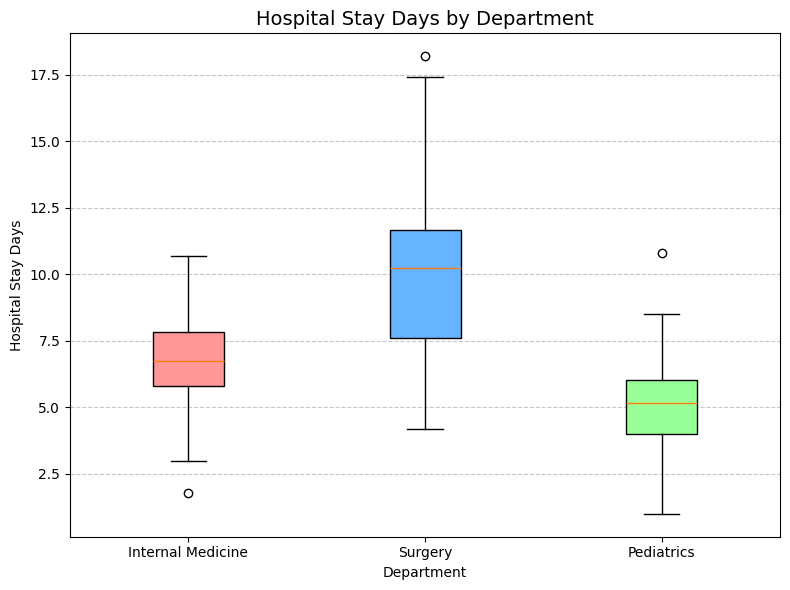

In [2]:
# 匯入所需套件
import pandas as pd
import matplotlib.pyplot as plt

# 讀取資料集
from pathlib import Path

data_file = "hospital_stay_by_department.csv"
df = pd.read_csv(path+"/"+data_file)

# 依科別整理各組住院天數資料
departments = ["Internal Medicine", "Surgery", "Pediatrics"]
stay_data = [df[df["Department"] == dept]["Hospital_Stay_Days"] for dept in departments]

# 建立箱型圖
plt.figure(figsize=(8, 6))  # 圖表大小（寬 x 高）

box = plt.boxplot(
    stay_data,
    tick_labels=departments,   # 各組名稱
    patch_artist=True          # 允許箱體填色
)

# 設定各箱體顏色
colors = ["#FF9999", "#66B3FF", "#99FF99"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# 設定圖表標題與軸標籤
plt.title("Hospital Stay Days by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Hospital Stay Days")

# 加入水平格線輔助閱讀
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 自動調整版面
plt.tight_layout()

# 顯示圖表
plt.show()

### Try it!：6. 實作範例：醫學領域 - 各科別住院天數分布分析（Box Plot）
院方希望在報告中以水平方向呈現各科別的住院天數分布，並同時標示各組平均值，方便與中位數比較。

**程式要求**
1. 讀取 `datasets/hospital_stay_by_department.csv`。
2. 使用 `plt.boxplot()` 繪製三個科別住院天數的「水平」箱型圖（`vert=False`）。
3. 加入 `showmeans=True` 顯示平均值，並設定標題與 x、y 軸標籤。


#### 📌 額外補充參考表

##### 🔧 常用參數（plt.boxplot）

| 參數             | 說明                       | 範例                          |
|------------------|----------------------------|-------------------------------|
| `tick_labels`    | 設定各組名稱               | `tick_labels=["A", "B"]`      |
| `patch_artist`   | 允許箱體填色               | `patch_artist=True`           |
| `showmeans`      | 顯示平均值標記             | `showmeans=True`              |
| `vert`           | 直向或橫向箱型圖           | `vert=False`（橫向）          |
| `whis`           | 鬚線長度（IQR 倍數）       | `whis=1.5`（預設）            |
| `widths`         | 箱體寬度                   | `widths=0.5`                  |
| `notch`          | 中位數凹口                 | `notch=True`                  |

你也可以改用 Seaborn 一行繪製分組箱型圖：
```python
import seaborn as sns
sns.boxplot(data=df, x="Department", y="Hospital_Stay_Days")
```


#### 📝 練習任務建議（設定參數的比較與應用）

1. **任務一：調整 `whis` 觀察離群值判定變化**
   測試 `whis=1.0`、`1.5`、`3.0`，觀察離群點數量的差異。

2. **任務二：加上 `notch=True` 呈現中位數凹口**
   觀察各組凹口是否重疊，初步判斷中位數差異是否明顯。

3. **任務三：調整 `widths` 改變箱體寬度**
   測試 `widths=0.3` 與 `0.8` 的視覺效果。

4. **任務四：嘗試不同配色組合**
   改為 `["salmon", "skyblue", "khaki"]` 測試對比與識別度。

5. **任務五：改用 Seaborn `sns.boxplot()` 繪製相同圖表**
   比較兩種寫法的程式簡潔度與預設樣式。
